In [10]:
# Time to import the libraries needed
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import nltk  # Natural Language Toolkit for various NLP tasks
from nltk.sentiment import SentimentIntensityAnalyzer  # For sentiment analysis
import re  # For regular expressions
import matplotlib.pyplot as plt  # For static visualizations
import seaborn as sns  # For enhanced visualizations
import plotly.express as px  # For interactive visualizations

In [11]:
# Download NLTK data for sentiment analysis
nltk.download('vader_lexicon')  # VADER sentiment analysis tool

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [12]:
# Loading the Challenge dataset
challenge_dataset_path = r'/content/Challenge dataset.xlsx'
df_volontaire = pd.read_excel(challenge_dataset_path, sheet_name= 'Volontaire')
df_2019 = pd.read_excel(challenge_dataset_path, sheet_name= '2019')

# Display the first few rows of each dataset
print("Volontaire Dataset:")
print(df_volontaire.info())
print("\n2019 Dataset:")
print(df_2019.info())

Volontaire Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 40 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   ID                                                                                         1846 non-null   object 
 1   Age                                                                                        1846 non-null   int64  
 2   Horodateur                                                                                 1846 non-null   object 
 3   Niveau_d'etude                                                                             1846 non-null   object 
 4   Genre_                                                                                     1846 non-null   object 
 5   Taille_                     

In [13]:
# Checking for missing values in both datasets
print("Missing values in Volontaire dataset:")
print(df_volontaire.isnull().sum())

print("\nMissing values in 2019 dataset:")
print(df_2019.isnull().sum())

Missing values in Volontaire dataset:
ID                                                                                              0
Age                                                                                             0
Horodateur                                                                                      0
Niveau_d'etude                                                                                  0
Genre_                                                                                          0
Taille_                                                                                      1786
Poids                                                                                        1742
Situation_Matrimoniale_(SM)                                                                     0
Profession_                                                                                     0
Arrondissement_de_résidence_                                                    

In [15]:
# Displaying the columns in the Volontaires dataset
volontaire_columns_list = list(df_volontaire.columns)
print("Columns in volontaire dataset:")
print(volontaire_columns_list)

# Displaying the columns in the 2019 dataset
data_2019_columns_list = list(df_2019.columns)
print("\nColumns in 2019 dataset:")
print(data_2019_columns_list)

Columns in volontaire dataset:
['ID', 'Age', 'Horodateur', "Niveau_d'etude", 'Genre_', 'Taille_', 'Poids', 'Situation_Matrimoniale_(SM)', 'Profession_', 'Arrondissement_de_résidence_', 'Quartier_de_Résidence_', 'Nationalité_', 'Religion_', 'A-t-il_(elle)_déjà_donné_le_sang_', 'Si_oui_preciser_la_date_du_dernier_don._', 'Taux_d’hémoglobine_', 'ÉLIGIBILITÉ_AU_DON.', 'Raison_indisponibilité__[Est_sous_anti-biothérapie__]', 'Raison_indisponibilité__[Taux_d’hémoglobine_bas_]', 'Raison_indisponibilité__[date_de_dernier_Don_<_3_mois_]', 'Raison_indisponibilité__[IST_récente_(Exclu_VIH,_Hbs,_Hcv)]', 'Date_de_dernières_règles_(DDR)__', 'Raison_de_l’indisponibilité_de_la_femme_[La_DDR_est_mauvais_si_<14_jour_avant_le_don]', 'Raison_de_l’indisponibilité_de_la_femme_[Allaitement_]', 'Raison_de_l’indisponibilité_de_la_femme_[A_accoucher_ces_6_derniers_mois__]', 'Raison_de_l’indisponibilité_de_la_femme_[Interruption_de_grossesse__ces_06_derniers_mois]', 'Raison_de_l’indisponibilité_de_la_femme_[est_

In [16]:
# Filling the missing values in the 'Si_autres_raison_préciser_' column with an empty string
df_volontaire['Si_autres_raison_préciser_'] = df_volontaire['Si_autres_raison_préciser_'].fillna('')
df_2019['Si autres raison préciser'] = df_2019['Si autres raison préciser'].fillna('')

In [18]:
# Function to clean the text data
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    return text

# Applying the cleaning function to the relevant column in both datasets
df_volontaire['cleaned_feedback'] = df_volontaire['Si_autres_raison_préciser_'].apply(clean_text)
df_2019['cleaned_feedback'] = df_2019['Si autres raison préciser'].apply(clean_text)

In [23]:
# Printing all feedback content from the Volontaires dataset
print("Feedback content in Volontaires dataset:")
print(df_volontaire['cleaned_feedback'].to_string(index=False))  # Use to_string to avoid truncation

# Printing all feedback content from the 2019 dataset
print("\nFeedback content in 2019 dataset:")
print(df_2019['cleaned_feedback'].to_string(index=False))  # Use to_string to avoid truncation

Feedback content in Volontaires dataset:
                                                  
                                                  
                               aucune information 
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                                  
                                         

In [24]:
# Initialize the SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Function to analyze sentiment
def analyze_sentiment(feedback):
    sentiment_scores = sia.polarity_scores(feedback)
    return sentiment_scores['compound']

# Apply the sentiment analysis function to the cleaned feedback
df_volontaire['sentiment_score'] = df_volontaire['cleaned_feedback'].apply(analyze_sentiment)
df_2019['sentiment_score'] = df_2019['cleaned_feedback'].apply(analyze_sentiment)

In [25]:
# Function to classify sentiment based on the compound score
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the classification function to the sentiment scores
df_volontaire['sentiment_category'] = df_volontaire['sentiment_score'].apply(classify_sentiment)
df_2019['sentiment_category'] = df_2019['sentiment_score'].apply(classify_sentiment)

In [26]:
# Count sentiment categories for Volontaires dataset
print("Sentiment counts in Volontaires dataset:")
print(df_volontaire['sentiment_category'].value_counts())

# Count sentiment categories for 2019 dataset
print("\nSentiment counts in 2019 dataset:")
print(df_2019['sentiment_category'].value_counts())

Sentiment counts in Volontaires dataset:
sentiment_category
Neutral    1846
Name: count, dtype: int64

Sentiment counts in 2019 dataset:
sentiment_category
Neutral    1915
Name: count, dtype: int64


<ipython-input-27-f5efacd89f2a>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_volontaire, x='sentiment_category', palette='Set2')


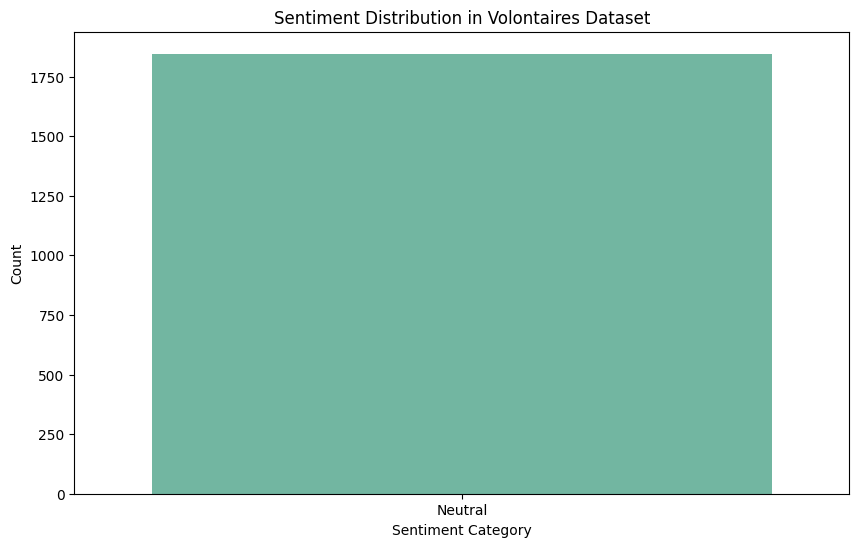

<ipython-input-27-f5efacd89f2a>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_2019, x='sentiment_category', palette='Set2')


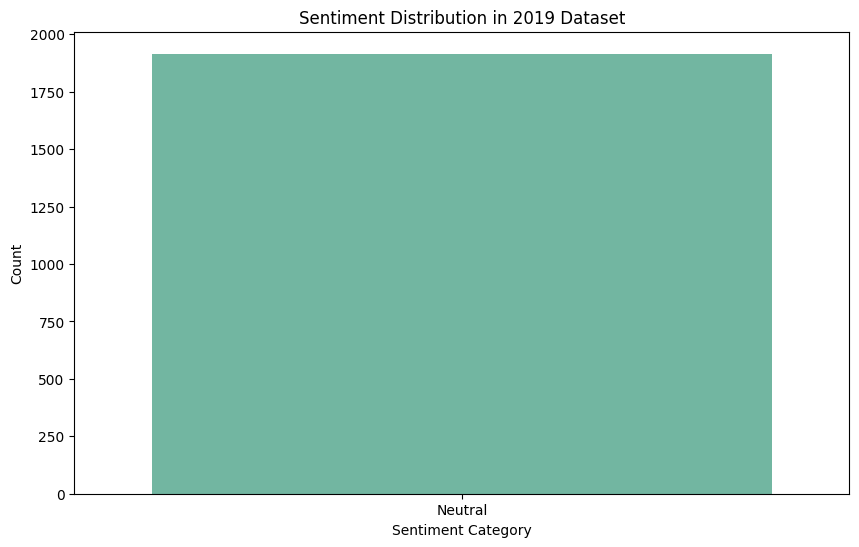

In [27]:
# Visualize the sentiment distribution for Volontaires dataset
plt.figure(figsize=(10, 6))
sns.countplot(data=df_volontaire, x='sentiment_category', palette='Set2')
plt.title('Sentiment Distribution in Volontaires Dataset')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

# Visualize the sentiment distribution for 2019 dataset
plt.figure(figsize=(10, 6))
sns.countplot(data=df_2019, x='sentiment_category', palette='Set2')
plt.title('Sentiment Distribution in 2019 Dataset')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

In [28]:
pip install wordcloud matplotlib

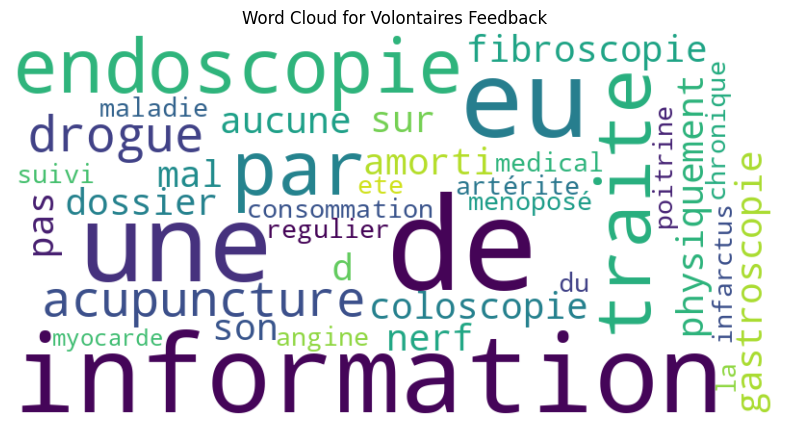

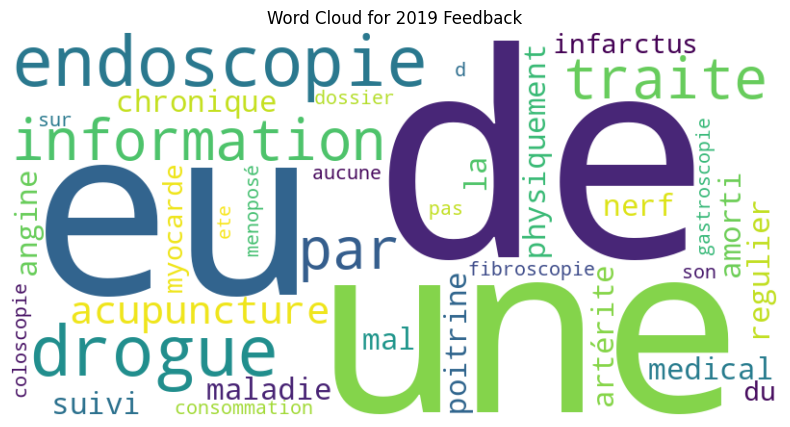

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all feedback into a single string for the Volontaires dataset
volontaire_text = ' '.join(df_volontaire['cleaned_feedback'])

# Generate a word cloud for the Volontaires dataset
wordcloud_volontaire = WordCloud(width=800, height=400, background_color='white').generate(volontaire_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_volontaire, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title('Word Cloud for Volontaires Feedback')
plt.show()

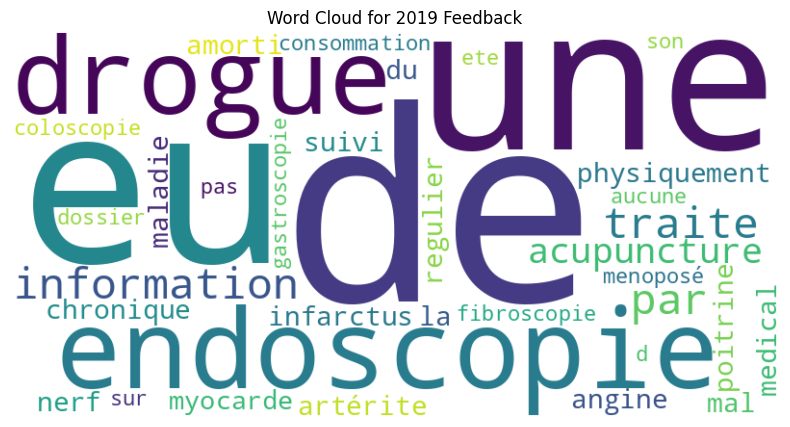

In [32]:
# Combine all feedback into a single string for the 2019 dataset
data_2019_text = ' '.join(df_2019['cleaned_feedback'])

# Generate a word cloud for the 2019 dataset
wordcloud_2019 = WordCloud(width=800, height=400, background_color='white').generate(data_2019_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_2019, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title('Word Cloud for 2019 Feedback')
plt.show()